In [ ]:
import random as rnd

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bluebikes_analysis.config import LOCAL_DATA_DIR

from bluebikes_analysis.plots import (
    COLORS,
    plot_daily_longterm,
    plot_correlation_comparison
)

In [47]:
timeseries_dir = LOCAL_DATA_DIR / "processed" / "trips"

station_name = "B32003"
station_file = timeseries_dir / f"station/{station_name}_morning_demand.csv"
station_df = pd.read_csv(station_file)

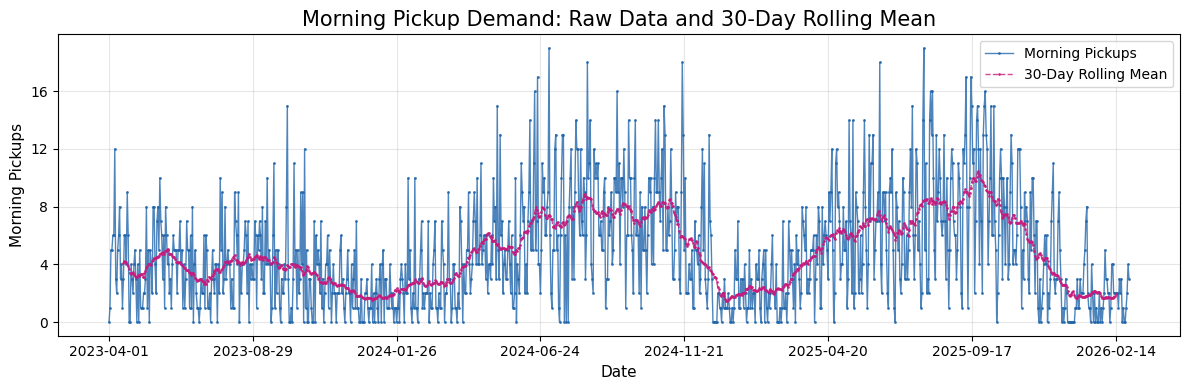

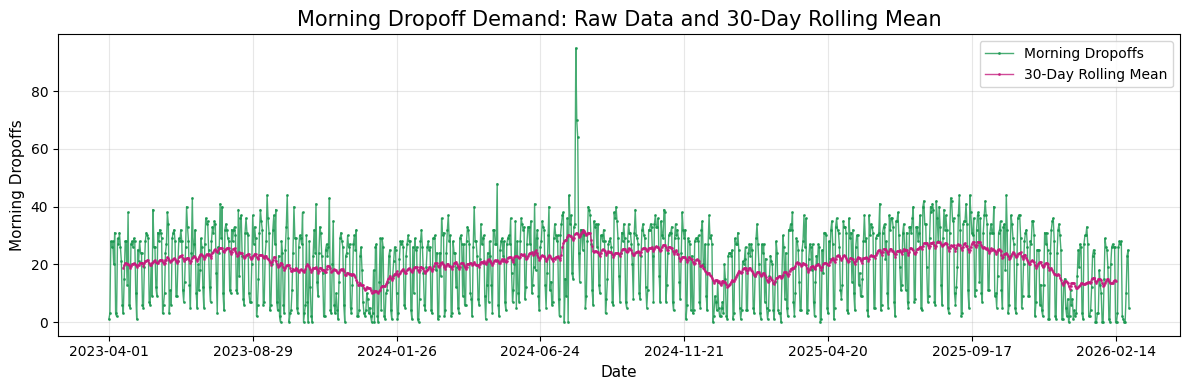

In [48]:
# Calculate rolling statistics (30-day window)
station_df = station_df.sort_values('date')
station_df['pickups_rolling_mean'] = station_df['morning_pickups'].rolling(window=30, center=True).mean()
station_df['dropoffs_rolling_mean'] = station_df['morning_dropoffs'].rolling(window=30, center=True).mean()

# Plot 1: Time series with rolling mean
plot_daily_longterm(
    station_df.set_index("date"),
    columns_to_plot=['morning_pickups', 'pickups_rolling_mean'],
    title='Morning Pickup Demand: Raw Data and 30-Day Rolling Mean',
    xlabel='Date',
    ylabel='Morning Pickups',
    color_list=[COLORS[7], COLORS[1]],
    linestyle_list=['-', '--'],
    legend_labels=['Morning Pickups', '30-Day Rolling Mean'],
    figsize=(12,4)
)

# Plot 2: Rolling standard deviation (separate plot)
plot_daily_longterm(
    station_df.set_index("date"),
    columns_to_plot=['morning_dropoffs', 'dropoffs_rolling_mean'],
    title='Morning Dropoff Demand: Raw Data and 30-Day Rolling Mean',
    xlabel='Date',
    ylabel='Morning Dropoffs',
    color_list=[COLORS[5], COLORS[1]],
    legend_labels=['Morning Dropoffs', '30-Day Rolling Mean'],
    figsize=(12,4)
)

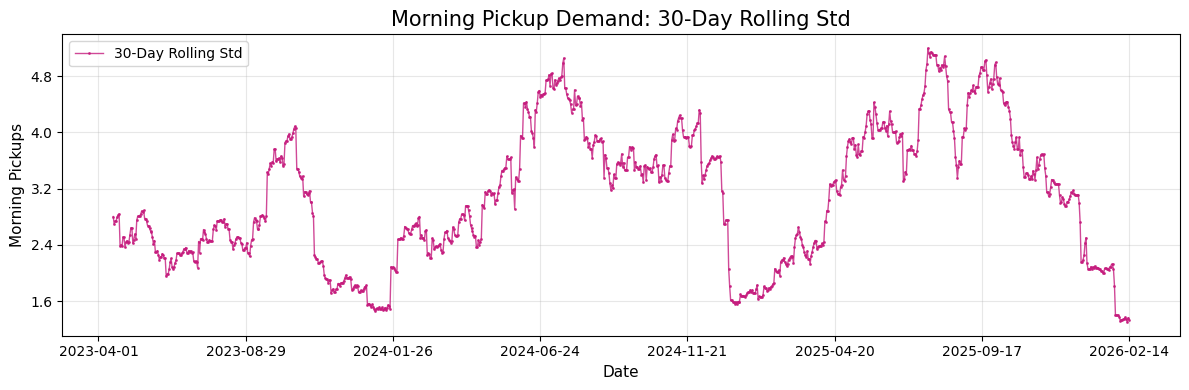

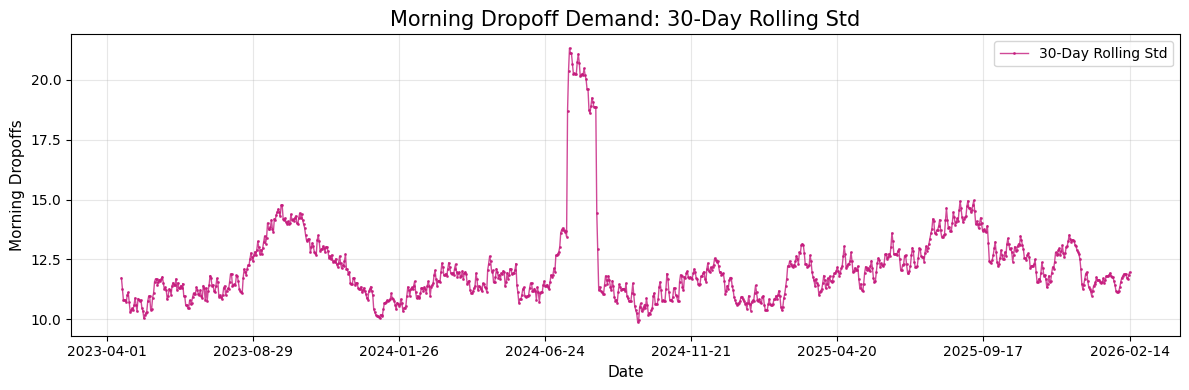

In [49]:
# Calculate rolling statistics (30-day window)
station_df = station_df.sort_values('date')
station_df['pickups_rolling_std'] = station_df['morning_pickups'].rolling(window=30, center=True).std()
station_df['dropoffs_rolling_std'] = station_df['morning_dropoffs'].rolling(window=30, center=True).std()

# Plot 1: Time series with rolling std
plot_daily_longterm(
    station_df.set_index("date"),
    columns_to_plot=['pickups_rolling_std'],
    title='Morning Pickup Demand: 30-Day Rolling Std',
    xlabel='Date',
    ylabel='Morning Pickups',
    color_list=[COLORS[1]],
    linestyle_list=['-', '--'],
    legend_labels=['30-Day Rolling Std'],
    figsize=(12,4)
)

# Plot 2: Rolling standard deviation (separate plot)
plot_daily_longterm(
    station_df.set_index("date"),
    columns_to_plot=['dropoffs_rolling_std'],
    title='Morning Dropoff Demand: 30-Day Rolling Std',
    xlabel='Date',
    ylabel='Morning Dropoffs',
    color_list=[COLORS[1]],
    legend_labels=['30-Day Rolling Std'],
    figsize=(12,4)
)

## Baseline: Raw Data Stationarity Test

Before applying transformations, we establish the baseline using the Augmented Dickey-Fuller test on raw morning pickups and dropoffs counts.

In [50]:
from statsmodels.tsa.stattools import adfuller

In [51]:
# Perform ADF test
result = adfuller(station_df['morning_pickups'].dropna(), autolag='AIC')
adf_stat, p_value, n_lags, n_obs, crit_vals = result[0], result[1], result[2], result[3], result[4]

print("ADF Test Results (Raw Data):")
print(f"  Test Statistic: {adf_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Critical Value (5%): {crit_vals['5%']:.4f}")
print(f"  Conclusion: {'Stationary' if p_value < 0.05 else 'Non-stationary'} (α=0.05)")

ADF Test Results (Raw Data):
  Test Statistic: -2.5984
  P-value: 0.0933
  Critical Value (5%): -2.8643
  Conclusion: Non-stationary (α=0.05)


In [52]:
# Perform ADF test
result = adfuller(station_df['morning_dropoffs'].dropna(), autolag='AIC')
adf_stat, p_value, n_lags, n_obs, crit_vals = result[0], result[1], result[2], result[3], result[4]

print("ADF Test Results (Raw Data):")
print(f"  Test Statistic: {adf_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Critical Value (5%): {crit_vals['5%']:.4f}")
print(f"  Conclusion: {'Stationary' if p_value < 0.05 else 'Non-stationary'} (α=0.05)")

ADF Test Results (Raw Data):
  Test Statistic: -3.6060
  P-value: 0.0056
  Critical Value (5%): -2.8643
  Conclusion: Stationary (α=0.05)


## Transformation Methods for Achieving Stationarity

Having established non-stationarity in the raw series (ADF p-value = 0.076), we now test four transformation approaches to achieve stationarity—a prerequisite for ARIMA modeling. Each method targets different sources of non-stationarity: trend, seasonality, or variance heterogeneity.

For each transformation, we evaluate: (1) visual appearance, (2) ADF test results, (3) remaining autocorrelation structure (ACF), and (4) practical trade-offs in interpretability and data loss.

### Method 1: First Differencing

First differencing transforms the series from levels to changes: $\nabla Y_t = Y_t - Y_{t-1}$. This removes stochastic trends by focusing on period-to-period variation rather than absolute values.

In [53]:
# Apply first differencing
station_df['first_diff_pickups'] = station_df['morning_pickups'].diff()

# Run ADF test
result = adfuller(station_df['first_diff_pickups'].dropna(), autolag='AIC')
adf_stat, p_value = result[0], result[1]

print("ADF Test Results (First Differencing):")
print(f"  Test Statistic: {adf_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Conclusion: {'Stationary' if p_value < 0.05 else 'Non-stationary'} (α=0.05)")

ADF Test Results (First Differencing):
  Test Statistic: -10.8474
  P-value: 0.0000
  Conclusion: Stationary (α=0.05)


In [54]:
# Apply first differencing
station_df['first_diff_dropoffs'] = station_df['morning_dropoffs'].diff()

# Run ADF test
result = adfuller(station_df['first_diff_dropoffs'].dropna(), autolag='AIC')
adf_stat, p_value = result[0], result[1]

print("ADF Test Results (First Differencing):")
print(f"  Test Statistic: {adf_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Conclusion: {'Stationary' if p_value < 0.05 else 'Non-stationary'} (α=0.05)")

ADF Test Results (First Differencing):
  Test Statistic: -11.4039
  P-value: 0.0000
  Conclusion: Stationary (α=0.05)


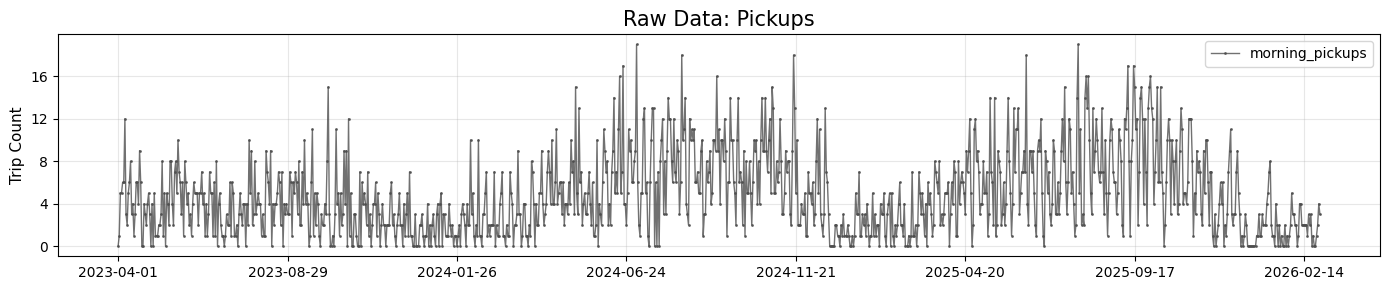

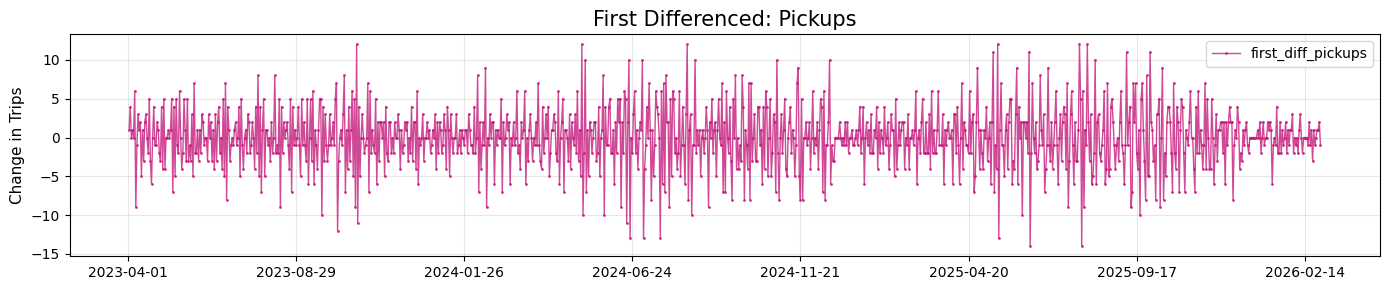

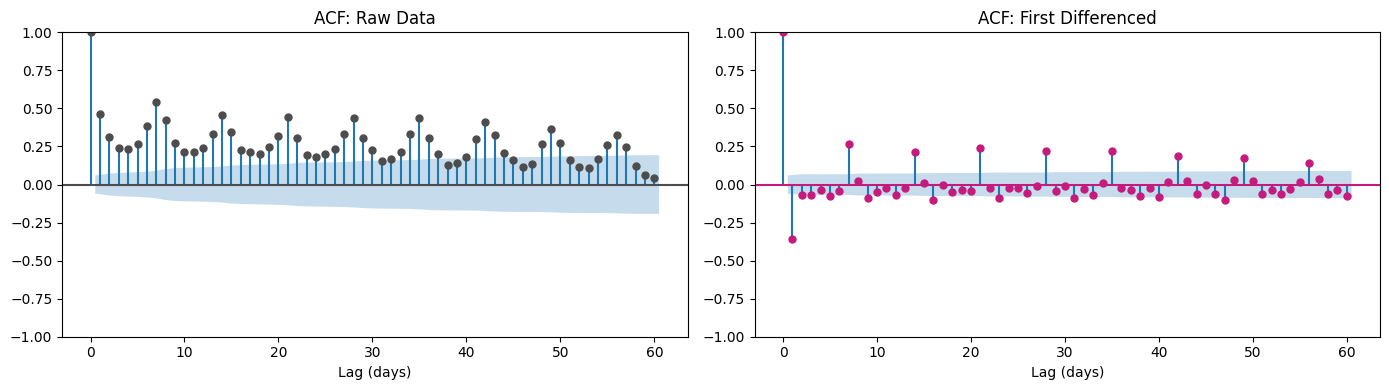

In [ ]:
# Set index for plotting
df_daily_indexed = station_df.set_index('date')

# Plot 1: Time series comparison
plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['morning_pickups'],
    title='Raw Data: Pickups',
    ylabel='Trip Count',
    color_list=[COLORS[11]],
    figsize=(14, 3)
)

plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['first_diff_pickups'],
    title='First Differenced: Pickups',
    ylabel='Change in Trips',
    color_list=[COLORS[1]],
    figsize=(14, 3)
)

print()

# Plot 2: ACF comparison
plot_correlation_comparison(
    df_daily_indexed,
    columns_to_compare=['morning_pickups', 'first_diff_pickups'],
    titles=['ACF: Raw Data', 'ACF: First Differenced'],
    color_list=[COLORS[11], COLORS[1]],
    figsize=(14, 4)
)

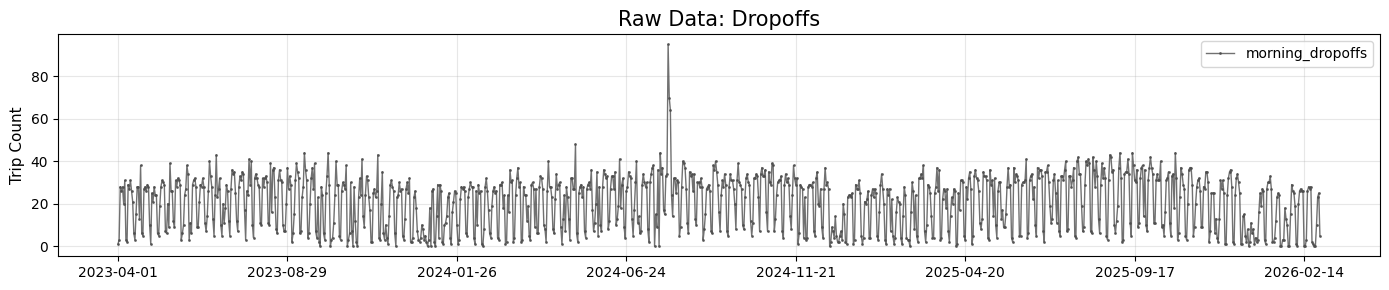

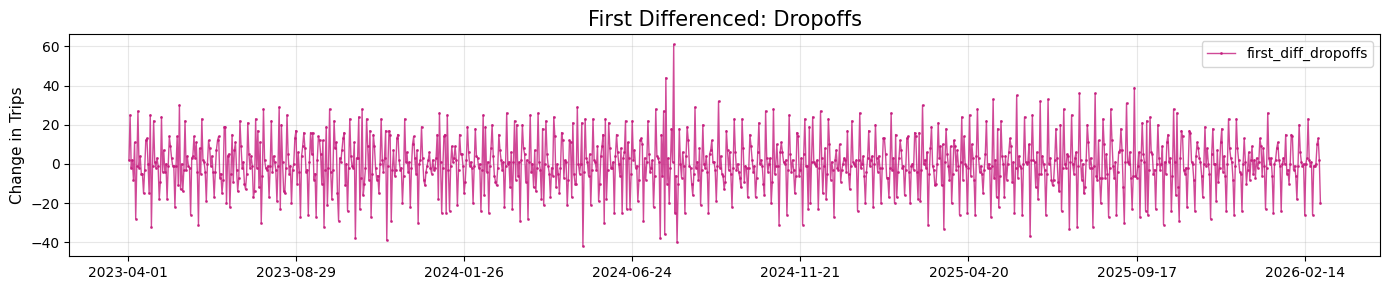

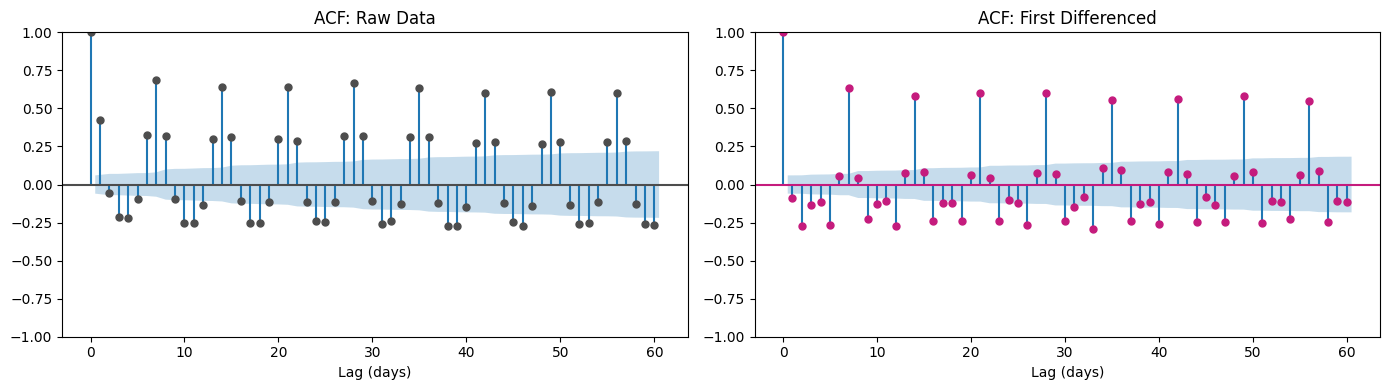

In [ ]:
# Set index for plotting
df_daily_indexed = station_df.set_index('date')

# Plot 1: Time series comparison
plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['morning_dropoffs'],
    title='Raw Data: Dropoffs',
    ylabel='Trip Count',
    color_list=[COLORS[11]],
    figsize=(14, 3)
)

plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['first_diff_dropoffs'],
    title='First Differenced: Dropoffs',
    ylabel='Change in Trips',
    color_list=[COLORS[1]],
    figsize=(14, 3)
)

print()

# Plot 2: ACF comparison
plot_correlation_comparison(
    df_daily_indexed,
    columns_to_compare=['morning_dropoffs', 'first_diff_dropoffs'],
    titles=['ACF: Raw Data', 'ACF: First Differenced'],
    color_list=[COLORS[11], COLORS[1]],
    figsize=(14, 4)
)